# **Modelo Baseline**

Librerias necesarias para realizar el modelo magico

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.dummy import DummyClassifier

**Carga de los registros perdidos**

In [ ]:
file_path = 'bosque_maldito_limpio.csv'
df = pd.read_csv(file_path)

In [ ]:
print(f"Registros cargados: {df.shape[0]} incursiones, {df.shape[1]} atributos.")

Registros cargados: 808 incursiones, 33 atributos.


Cargamos el dataset que limpiamos previamente. df.shape nos confirma las dimensiones: cuántas filas (incursiones de héroes) y cuántas columnas (atributos) tenemos para trabajar. Es vital verificar esto para asegurar que la limpieza anterior no eliminó demasiados datos.

**Preparación de datos**

In [ ]:
X = df.drop(['exito', 'mazmorra'], axis=1)
y = df['exito']

Separamos las características (X) del objetivo (y).

Eliminamos exito de X porque es lo que queremos predecir (sería hacer trampa tenerlo).

Eliminamos mazmorra porque es un texto (string) repetitivo que no aporta información numérica al modelo (todas las filas son del mismo bosque).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

* División Sagrada: Partimos los datos en 80% para Entrenamiento (train) y 20% para Prueba (test).

* random_state=42: Semilla para que el resultado sea siempre el mismo (reproducible).

* stratify=y: Crucial. Asegura que la proporción de victorias/derrotas se mantenga igual en el entrenamiento y en la prueba. Si el bosque es muy letal, no queremos que todas las victorias caigan por azar solo en el set de prueba.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* Escalado (Normalización): Los algoritmos lineales (como la Regresión Logística) se confunden si una variable tiene valores enormes (ej: Vida = 100) y otra pequeños (ej: Agilidad = 5).StandardScaler pone todo en la misma escala (media 0, desviación 1).

El escalador se 'ajusta' (fit) SOLO con los datos de entrenamiento para no 'espiar' los datos de prueba.

**Entrenamiento (Los Modelos Baseline)**

Dummy Classifier

In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
print(accuracy_score(y_test, y_pred_dummy))

0.8827160493827161


El Baseline Cero: Este modelo no aprende nada. Solo predice la clase mayoritaria (ej: si la mayoría muere, predice que todos mueren). Es nuestra referencia mínima. Si nuestra IA compleja no supera a este modelo 'tonto', el proyecto ha fallado

Regresión Logística

In [ ]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

Modelo Lineal: Intenta trazar una línea recta que separe el éxito del fracaso. Nos dice si hay una relación simple y directa entre los atributos (más vida = más éxito). Usamos los datos escalados (X_train_scaled) aquí.

Árbol de Decisón

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
y_prob_tree = tree_clf.predict_proba(X_test)[:, 1]

Modelo No Lineal: Crea un diagrama de flujo de decisiones (ej: Tiene Olenthero? -> Sí -> Vida > 5?).

max_depth=5: Limitamos la profundidad para que el árbol no memorice los datos de memoria (overfitting), obligándolo a generalizar patrones.

**Evaluación (El ojo del oráculo)**

In [ ]:
def evaluar_modelo(nombre, y_real, y_pred, y_prob=None):

    print(f"\n--- {nombre} ---")
    print(f"Accuracy: {accuracy_score(y_real, y_pred):.4f}")

    if y_prob is not None:
        print(f"ROC-AUC: {roc_auc_score(y_real, y_prob):.4f}")

    print("\nReporte de Clasificación:")
    print(classification_report(y_real, y_pred))

    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

Función auxiliar para no repetir código. Calcula:

* Accuracy: % global de aciertos.

* ROC-AUC: Capacidad del modelo para distinguir clases (importante si hay desbalance de datos).

* Confusion Matrix: Nos muestra visualmente los Falsos Positivos (decir que ganan y mueren) vs Falsos Negativos.

* Arriba-Izquierda (Verdadero Negativo): El modelo dijo Morirán y murieron. (Acierto).

* Abajo-Derecha (Verdadero Positivo): El modelo dijo Ganarán y ganaron. (Acierto).

* Arriba-Derecha (Falso Positivo - La Ilusión Mortal): El modelo dijo Ganarán, pero el equipo murió horriblemente. (Error grave: mandamos héroes a la muerte).

* Abajo-Izquierda (Falso Negativo - La Oportunidad Perdida): El modelo dijo Morirán, pero habrían ganado. (Error: somos demasiado pesimistas).


--- Baseline Dummy (Referencia) ---
Accuracy: 0.8827

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       143
           1       0.00      0.00      0.00        19

    accuracy                           0.88       162
   macro avg       0.44      0.50      0.47       162
weighted avg       0.78      0.88      0.83       162



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


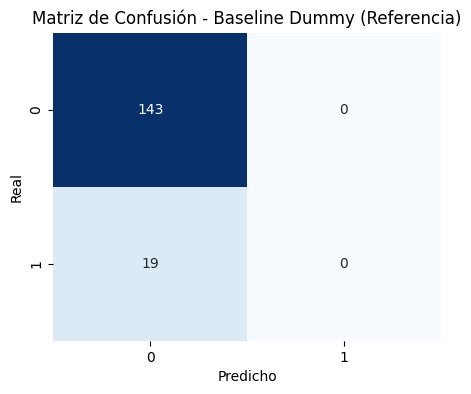

In [ ]:
evaluar_modelo("Baseline Dummy (Referencia)", y_test, y_pred_dummy)


--- Regresión Logística ---
Accuracy: 0.8704
ROC-AUC: 0.6117

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       143
           1       0.00      0.00      0.00        19

    accuracy                           0.87       162
   macro avg       0.44      0.49      0.47       162
weighted avg       0.78      0.87      0.82       162



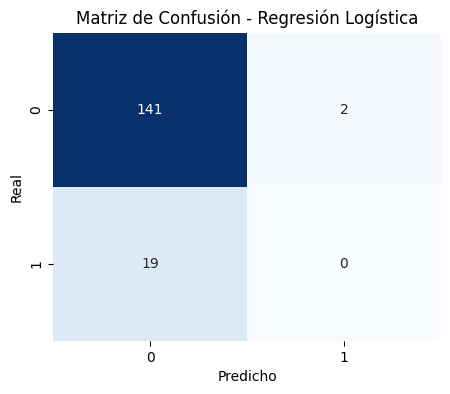

In [ ]:
evaluar_modelo("Regresión Logística", y_test, y_pred_log, y_prob_log)


--- Árbol de Decisión ---
Accuracy: 0.8272
ROC-AUC: 0.5403

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       143
           1       0.00      0.00      0.00        19

    accuracy                           0.83       162
   macro avg       0.44      0.47      0.45       162
weighted avg       0.77      0.83      0.80       162



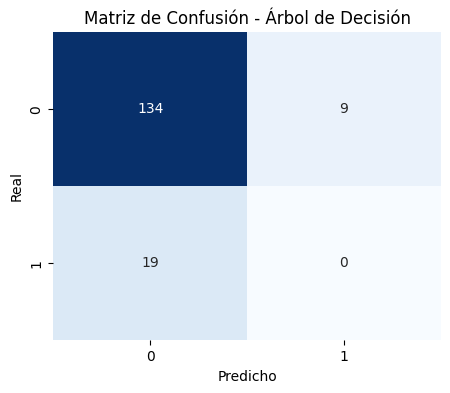

In [ ]:
evaluar_modelo("Árbol de Decisión", y_test, y_pred_tree, y_prob_tree)

**Importancia de Atributos**

In [ ]:
importancia = pd.DataFrame({
    'Atributo': X.columns,
    'Importancia': tree_clf.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)

La Revelación: Le preguntamos al Árbol de Decisión cuáles fueron las características más útiles para dividir a los ganadores de los perdedores. Esto nos ayuda a entender la 'física' de la mazmorra (ej: ¿Es más importante la agilidad de Lamyreth o la fuerza de Basajorn?)."

/tmp/ipython-input-943909929.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Atributo', data=importancia, palette='viridis')


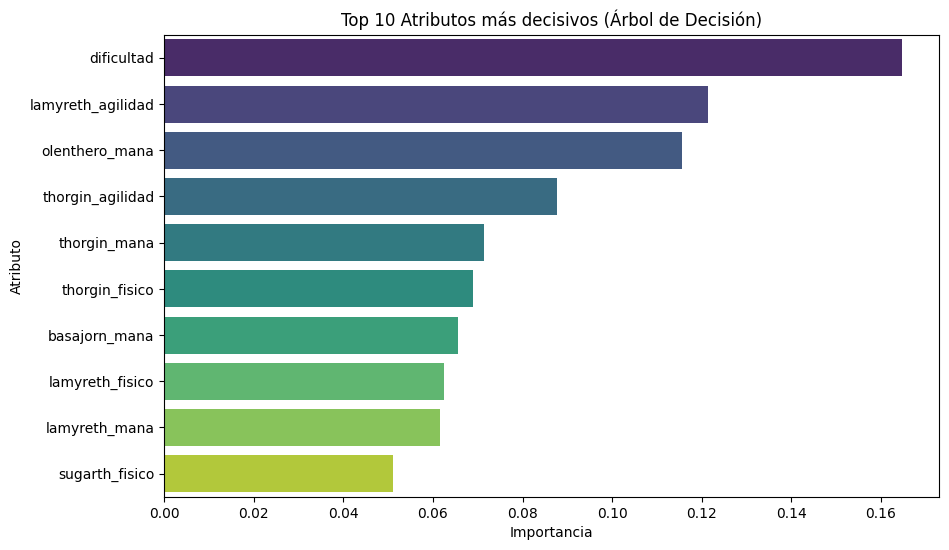

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Atributo', data=importancia, palette='viridis')
plt.title('Top 10 Atributos más decisivos (Árbol de Decisión)')
plt.show()

* **Consistencia del Dominio:** La dificultad se mantiene indiscutiblemente como el atributo más decisivo. Confirma que la viabilidad de la misión está dictada principalmente por el entorno.

* **Cambio de Paradigma en los Héroes Clave:** El árbol de decisión ha identificado dependencias críticas en estadísticas de héroes específicos. La agilidad de Lamyreth (lamyreth_agilidad) y el maná de Olenthero (olenthero_mana) emergen como los factores de supervivencia más importantes después de la dificultad.

* **Umbrales de Rendimiento:** La predominancia de atributos numéricos continuos (físico, maná, agilidad) sugiere que el modelo está encontrando "puntos de corte" específicos. No basta con llevar a un héroe; este debe cumplir con requisitos mínimos de estadísticas para garantizar la victoria.